In [1]:
import ehtim as eh
import ehtim.const_def as ehc

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

RADPERUAS = ehc.RADPERUAS

Welcome to eht-imaging!



In [2]:
### Gaussian visibility function and related coordinate transformations

def uas_to_rad(x_uas): #convert microarcseconds to radians (for ehtim)
    return x_uas * RADPERUAS

def gauss_visibility(flux, x0_uas, y0_uas, fwhm_uas, u, v): #analytical fourier transform
    """
    Compute the Gaussian visibility function for given parameters.
    Args:  flux: Total flux density of the Gaussian component
           x0_uas, y0_uas: Position of the Gaussian component in microarcseconds
           fwhm_uas: Full width at half maximum of the Gaussian component in microarcseconds
           u, v: Spatial frequency coordinates in units of inverse radians
    Returns:    Complex visibility value at the given spatial frequencies (u, v)
    """
    x0 = uas_to_rad(x0_uas)
    y0 = uas_to_rad(y0_uas)
    sigma = uas_to_rad(fwhm_uas) / (2 * np.sqrt(2 * np.log(2))) # Convert FWHM to standard deviation
    G= np.exp(-2 * np.pi**2 * sigma**2 * (u**2 + v**2)) # Gaussian visibility amplitude
    phase = np.exp(2j * np.pi * (u * x0 + v * y0)) # Gaussian visibility phase
    
    return flux * G * phase

def get_map_coords(x_phys, y_phys, dx_offset, dy_offset):  # comp position on the map = comp position in physical plane - offset of the map origin from the BH
    """
    Compute the coordinates of a component in the map plane given its physical coordinates and the map origin offset.
    Args:  x_phys, y_phys: Physical coordinates of the component in microarcseconds
           dx_offset, dy_offset: Offset of the map origin from the BH in microarcseconds
    Returns:    Tuple containing the x and y coordinates of the component in the map plane
    """
    x_map = x_phys - dx_offset
    y_map = y_phys - dy_offset
    return x_map, y_map

def gauss_bh(flux, x_phys, y_phys, fwhm, u, v): # coordinates of the components in the physical plane (w/r to BH)
    return gauss_visibility(flux, x_phys, y_phys, fwhm, u, v)

def gauss_map(flux, x_phys, y_phys, fwhm, dx_offset, dy_offset, u, v): #coordinates of the components in the map plane (w/r to map origin)
    x_map, y_map = get_map_coords(x_phys, y_phys, dx_offset, dy_offset)
    return gauss_visibility(flux, x_map, y_map, fwhm, u, v)

update comments, add parameters and units, everything shoul be understood

- add name dreciption

In [3]:
freqs = [15e9, 43e9,86e9]
# set of frequencies
freq_labels = {
    15e9: "15 GHz",
    43e9: "43 GHz",
    86e9: "86 GHz"
}

In [4]:
#Fixed parameters for the model components (Fluxes in Jy, coordinates and sizes in microarcseconds)

x_core_15_true, y_core_15_true = -500.0, -200.0 # 15 ghz: coordinates of the core components in the physical plane (w/r to BH)
x_core_43_true, y_core_43_true = -250.0, -100.0 # 43 ghz: coordinates of the core components in the physical plane (w/r to BH)
x_core_86_true, y_core_86_true = -100.0, -10.0 # 86 ghz: coordinates of the core components in the physical plane (w/r to BH) 

fwhm_core_15_true, fwhm_core_43_true, fwhm_core_86_true = 250.0, 200.0, 150.0 # FWHM of the core components (in microarcseconds)

# jet components (shared parameters)
x_jet1_true, y_jet1_true, fwhm_jet1_true = -1500.0, -1500.0, 700.0 #coordinates and size of the jet components in the physical plane (w/r to BH)
x_jet2_true, y_jet2_true, fwhm_jet2_true = -3200.0, -3200.0, 1000.0 

# core component fluxes
flux_core_15, flux_core_43, flux_core_86 = 6.6, 9.8, 12.0
flux_j1_15, flux_j1_43, flux_j1_86 = 3.5, 2.0, 1.0
flux_j2_15, flux_j2_43, flux_j2_86 = 1.5, 0.7, 0.4

# core component coordinates on the map plane (microarcseconds)
x_map_core_15 = np.random.uniform(-50.0, 50.0)
y_map_core_15 = np.random.uniform(-50.0, 50.0)

x_map_core_43 = np.random.uniform(-50.0, 50.0)
y_map_core_43 = np.random.uniform(-50.0, 50.0)

x_map_core_86 = np.random.uniform(-50.0, 50.0)
y_map_core_86 = np.random.uniform(-50.0, 50.0)

# offsets between the true core positions and the map core positions
dx_15_true = x_core_15_true - x_map_core_15
dy_15_true = y_core_15_true - y_map_core_15

dx_43_true = x_core_43_true - x_map_core_43
dy_43_true = y_core_43_true - y_map_core_43

dx_86_true = x_core_86_true - x_map_core_86
dy_86_true = y_core_86_true - y_map_core_86

TRUE_OFFSETS = {
    15e9: (dx_15_true, dy_15_true),
    43e9: (dx_43_true, dy_43_true),
    86e9: (dx_86_true, dy_86_true)
}

##############################
# Saved reference from the decent run
SAVED_GOOD_TRUE = np.array([ # use as p_truE
    6.600, -500.000, -200.000, 250.000,
    9.800, -250.000, -100.000, 200.000,
    12.000, -100.000, -10.000, 150.000,
    3.500, 2.000, 1.000, -1500.000, -1500.000, 700.000,
    1.500, 0.700, 0.400, -3200.000, -3200.000, 1000.000,
    -483.934, -196.684, -170.395, -30.297, -66.089, -6.575,
])
SAVED_GOOD_GUESS = np.array([ # use as p0
    8.163, -616.589, -249.401, 194.793,
    11.759, -187.833, -78.453, 247.051,
    14.529, -122.202, -8.473, 176.757,
    4.371, 2.397, 0.840, -1147.656, -1740.177, 538.937,
    1.823, 0.871, 0.495, -3974.389, -2582.788, 762.313,
    -576.850, -226.252, -203.622, -36.128, -76.381, -7.910,
])
SAVED_GOOD_FIT = np.array([ # use as fit result
    6.550, -464.760, -197.541, 312.500,
    9.426, -266.639, -150.518, 164.204,
    12.068, -70.323, -12.232, 159.570,
    3.584, 1.799, 1.272, -1495.004, -1532.912, 745.109,
    1.422, 0.671, 0.234, -3167.592, -3338.567, 750.000,
    -452.117, -196.719, -187.491, -80.245, -36.278, -9.110,
])

In [5]:
# Optional randomization of TRUE / hardcoded parameters
"""
USE_RANDOM_TRUTH = True
RANDOM_TRUTH_SEED = None

# Options:
# ()                              -> use hardcoded values
# ("flux",)                       -> randomize only true fluxes
# ("position",)                   -> randomize only true component positions
# ("size",)                       -> randomize only true component sizes
# ("flux", "position", "size")    -> randomize fluxes, positions, and sizes
# ("all",)                        -> same as ("flux", "position", "size")
RANDOM_TRUTH_GROUPS = ("all",)

TRUTH_RANDOM_RANGES = {
    # Fluxes
    "flux_jy": (0.5, 15.0),
    "alpha_core": (0.0, 0.6),
    "alpha_jet": (-1.2, -0.45),

    # Sizes
    "core_fwhm_uas": (80.0, 500.0),
    "jet_fwhm_uas": (500.0, 2500.0),

    # Core positions: enforced as r_86 < r_43 < r_15
    "core86_radius_uas": (10.0, 100.0),
    "core43_extra_radius_uas": (100.0, 250.0),
    "core15_extra_radius_uas": (250.0, 500.0),

    # Scatter perpendicular to jet axis
    "core86_transverse_sigma_uas": 30.0,
    "core43_transverse_sigma_uas": 45.0,
    "core15_transverse_sigma_uas": 60.0,

    # Jet positions: enforced as r_j1 < r_j2
    "jet1_min_radius_uas": 750.0,
    "jet1_extra_from_core15_uas": 100.0,
    "jet1_max_radius_uas": 2000.0,
    "jet2_extra_from_jet1_uas": (1000.0, 2500.0),

    # Jet transverse scatter
    "jet1_transverse_sigma_uas": 150.0,
    "jet2_transverse_sigma_uas": 300.0,

    # Field of view checks
    "sim_fov_uas": 20000.0,
    "edge_margin_uas": 600.0,
}

def normalize_truth_groups(groups):
    if groups is None:
        return set()
    if isinstance(groups, str):
        groups = (groups,)

    aliases = {
        "all": "all",
        "fluxes": "flux",
        "flujos": "flux",
        "positions": "position",
        "posiciones": "position",
        "sizes": "size",
        "tamanos": "size",
        "tamaños": "size",
    }

    normalized = {aliases.get(group, group) for group in groups}

    if "all" in normalized:
        return {"flux", "position", "size"}

    return normalized


def current_truth_params():
    return dict(
        S_c15=flux_core_15, S_c43=flux_core_43, S_c86=flux_core_86,
        S_j1_15=flux_j1_15, S_j1_43=flux_j1_43, S_j1_86=flux_j1_86,
        S_j2_15=flux_j2_15, S_j2_43=flux_j2_43, S_j2_86=flux_j2_86,

        x_c15=x_core_15_true, y_c15=y_core_15_true, fwhm_c15=fwhm_core_15_true,
        x_c43=x_core_43_true, y_c43=y_core_43_true, fwhm_c43=fwhm_core_43_true,
        x_c86=x_core_86_true, y_c86=y_core_86_true, fwhm_c86=fwhm_core_86_true,

        x_j1=x_jet1_true, y_j1=y_jet1_true, fwhm_j1=fwhm_jet1_true,
        x_j2=x_jet2_true, y_j2=y_jet2_true, fwhm_j2=fwhm_jet2_true,
    )


def power_law_fluxes_in_range(rng, alpha_range, ranges=TRUTH_RANDOM_RANGES, ref_freq=43e9):
    flux_range = ranges["flux_jy"]
    alpha = rng.uniform(*alpha_range)

    ref_lows = [flux_range[0] / (freq / ref_freq)**alpha for freq in freqs]
    ref_highs = [flux_range[1] / (freq / ref_freq)**alpha for freq in freqs]

    ref_low = max(ref_lows)
    ref_high = min(ref_highs)

    if ref_low >= ref_high:
        raise RuntimeError("Flux range is incompatible with this alpha range.")

    s_ref = rng.uniform(ref_low, ref_high)
    fluxes = np.array([s_ref * (freq / ref_freq)**alpha for freq in freqs])

    return fluxes, alpha


def core_fluxes_dominate(params):
    return (
        params["S_c15"] > params["S_j1_15"] > params["S_j2_15"]
        and params["S_c43"] > params["S_j1_43"] > params["S_j2_43"]
        and params["S_c86"] > params["S_j1_86"] > params["S_j2_86"]
    )


def sample_flux_params(rng, ranges=TRUTH_RANDOM_RANGES):
    for _ in range(2000):
        (S_c15, S_c43, S_c86), alpha_core = power_law_fluxes_in_range(
            rng,
            alpha_range=ranges["alpha_core"],
            ranges=ranges,
        )

        (S_j1_15, S_j1_43, S_j1_86), alpha_j1 = power_law_fluxes_in_range(
            rng,
            alpha_range=ranges["alpha_jet"],
            ranges=ranges,
        )

        (S_j2_15, S_j2_43, S_j2_86), alpha_j2 = power_law_fluxes_in_range(
            rng,
            alpha_range=ranges["alpha_jet"],
            ranges=ranges,
        )

        flux_params = dict(
            S_c15=S_c15, S_c43=S_c43, S_c86=S_c86,
            S_j1_15=S_j1_15, S_j1_43=S_j1_43, S_j1_86=S_j1_86,
            S_j2_15=S_j2_15, S_j2_43=S_j2_43, S_j2_86=S_j2_86,
        )

        if core_fluxes_dominate(flux_params):
            meta = dict(alpha_core=alpha_core, alpha_j1=alpha_j1, alpha_j2=alpha_j2)
            return flux_params, meta

    raise RuntimeError("Could not sample fluxes satisfying S_core > S_j1 > S_j2.")


def sample_size_params(rng, ranges=TRUTH_RANDOM_RANGES):
    fwhm_c86, fwhm_c43, fwhm_c15 = np.sort(
        rng.uniform(*ranges["core_fwhm_uas"], size=3)
    )

    return dict(
        fwhm_c15=fwhm_c15,
        fwhm_c43=fwhm_c43,
        fwhm_c86=fwhm_c86,
        fwhm_j1=rng.uniform(*ranges["jet_fwhm_uas"]),
        fwhm_j2=rng.uniform(*ranges["jet_fwhm_uas"]),
    )


def xy_from_axis(axis, distance_uas, transverse_uas=0.0):
    perp = np.array([-axis[1], axis[0]])
    xy = axis * distance_uas + perp * transverse_uas
    return float(xy[0]), float(xy[1])


def sample_position_params(rng, ranges=TRUTH_RANDOM_RANGES):
    pa = rng.uniform(0.0, 2.0 * np.pi)
    axis = np.array([np.cos(pa), np.sin(pa)])

    r_c86 = rng.uniform(*ranges["core86_radius_uas"])
    r_c43 = r_c86 + rng.uniform(*ranges["core43_extra_radius_uas"])
    r_c15 = r_c43 + rng.uniform(*ranges["core15_extra_radius_uas"])

    x_c86, y_c86 = xy_from_axis(
        axis,
        r_c86,
        rng.normal(0.0, ranges["core86_transverse_sigma_uas"]),
    )
    x_c43, y_c43 = xy_from_axis(
        axis,
        r_c43,
        rng.normal(0.0, ranges["core43_transverse_sigma_uas"]),
    )
    x_c15, y_c15 = xy_from_axis(
        axis,
        r_c15,
        rng.normal(0.0, ranges["core15_transverse_sigma_uas"]),
    )

    r_j1_low = max(
        ranges["jet1_min_radius_uas"],
        r_c15 + ranges["jet1_extra_from_core15_uas"],
    )
    r_j1_high = ranges["jet1_max_radius_uas"]

    if r_j1_low >= r_j1_high:
        raise RuntimeError("jet1 radius range is incompatible with core15 radius.")

    r_j1 = rng.uniform(r_j1_low, r_j1_high)
    r_j2 = r_j1 + rng.uniform(*ranges["jet2_extra_from_jet1_uas"])

    x_j1, y_j1 = xy_from_axis(
        axis,
        r_j1,
        rng.normal(0.0, ranges["jet1_transverse_sigma_uas"]),
    )
    x_j2, y_j2 = xy_from_axis(
        axis,
        r_j2,
        rng.normal(0.0, ranges["jet2_transverse_sigma_uas"]),
    )

    params = dict(
        x_c15=x_c15, y_c15=y_c15,
        x_c43=x_c43, y_c43=y_c43,
        x_c86=x_c86, y_c86=y_c86,
        x_j1=x_j1, y_j1=y_j1,
        x_j2=x_j2, y_j2=y_j2,
    )

    meta = dict(
        jet_pa_deg=np.degrees(pa) % 360.0,
        r_c86=r_c86,
        r_c43=r_c43,
        r_c15=r_c15,
        r_j1=r_j1,
        r_j2=r_j2,
    )

    return params, meta


def core_frequency_order_is_valid(params):
    r_c15 = np.hypot(params["x_c15"], params["y_c15"])
    r_c43 = np.hypot(params["x_c43"], params["y_c43"])
    r_c86 = np.hypot(params["x_c86"], params["y_c86"])

    return r_c86 < r_c43 < r_c15


def jet_order_is_valid(params):
    r_j1 = np.hypot(params["x_j1"], params["y_j1"])
    r_j2 = np.hypot(params["x_j2"], params["y_j2"])

    return r_j1 < r_j2


def component_fits_fov(x, y, fwhm, ranges=TRUTH_RANDOM_RANGES):
    half_width = ranges["sim_fov_uas"] / 2.0 - ranges["edge_margin_uas"]
    radius = fwhm / 2.0

    return (
        abs(x) + radius < half_width
        and abs(y) + radius < half_width
    )


def positions_fit_fov(params, ranges=TRUTH_RANDOM_RANGES):
    components = [
        (params["x_c15"], params["y_c15"], params["fwhm_c15"]),
        (params["x_c43"], params["y_c43"], params["fwhm_c43"]),
        (params["x_c86"], params["y_c86"], params["fwhm_c86"]),
        (params["x_j1"], params["y_j1"], params["fwhm_j1"]),
        (params["x_j2"], params["y_j2"], params["fwhm_j2"]),
    ]

    return all(component_fits_fov(x, y, fwhm, ranges=ranges) for x, y, fwhm in components)


def no_core_jet_overlap(params, margin_uas=0.0):
    cores = [
        (params["x_c15"], params["y_c15"], params["fwhm_c15"]),
        (params["x_c43"], params["y_c43"], params["fwhm_c43"]),
        (params["x_c86"], params["y_c86"], params["fwhm_c86"]),
    ]

    jets = [
        (params["x_j1"], params["y_j1"], params["fwhm_j1"]),
        (params["x_j2"], params["y_j2"], params["fwhm_j2"]),
    ]

    for x_c, y_c, fwhm_c in cores:
        for x_j, y_j, fwhm_j in jets:
            distance = np.hypot(x_c - x_j, y_c - y_j)
            min_distance = 0.5 * (fwhm_c + fwhm_j) + margin_uas

            if distance <= min_distance:
                return False

    return True


def recompute_offsets_from_map_core_positions():
    offsets = {
        15e9: (
            x_core_15_true - x_map_core_15,
            y_core_15_true - y_map_core_15,
        ),
        43e9: (
            x_core_43_true - x_map_core_43,
            y_core_43_true - y_map_core_43,
        ),
        86e9: (
            x_core_86_true - x_map_core_86,
            y_core_86_true - y_map_core_86,
        ),
    }

    return offsets


def sample_random_truth(rng, groups, ranges=TRUTH_RANDOM_RANGES):
    groups = normalize_truth_groups(groups)
    base_params = current_truth_params()

    for _ in range(2000):
        params = base_params.copy()
        meta = {}

        if "flux" in groups:
            flux_params, flux_meta = sample_flux_params(rng, ranges=ranges)
            params.update(flux_params)
            meta.update(flux_meta)

        if "size" in groups:
            size_params = sample_size_params(rng, ranges=ranges)
            params.update(size_params)

        if "position" in groups:
            position_params, position_meta = sample_position_params(rng, ranges=ranges)
            params.update(position_params)
            meta.update(position_meta)

        if (
            core_fluxes_dominate(params)
            and core_frequency_order_is_valid(params)
            and jet_order_is_valid(params)
            and positions_fit_fov(params, ranges=ranges)
            and no_core_jet_overlap(params)
        ):
            meta["randomized_groups"] = tuple(sorted(groups))
            return params, meta

    raise RuntimeError("Could not sample a valid random truth. Relax ranges or margins.")


def apply_truth_params(params):
    globals().update(dict(
        flux_core_15=params["S_c15"],
        flux_core_43=params["S_c43"],
        flux_core_86=params["S_c86"],
        flux_j1_15=params["S_j1_15"],
        flux_j1_43=params["S_j1_43"],
        flux_j1_86=params["S_j1_86"],
        flux_j2_15=params["S_j2_15"],
        flux_j2_43=params["S_j2_43"],
        flux_j2_86=params["S_j2_86"],

        x_core_15_true=params["x_c15"],
        y_core_15_true=params["y_c15"],
        fwhm_core_15_true=params["fwhm_c15"],
        x_core_43_true=params["x_c43"],
        y_core_43_true=params["y_c43"],
        fwhm_core_43_true=params["fwhm_c43"],
        x_core_86_true=params["x_c86"],
        y_core_86_true=params["y_c86"],
        fwhm_core_86_true=params["fwhm_c86"],

        x_jet1_true=params["x_j1"],
        y_jet1_true=params["y_j1"],
        fwhm_jet1_true=params["fwhm_j1"],
        x_jet2_true=params["x_j2"],
        y_jet2_true=params["y_j2"],
        fwhm_jet2_true=params["fwhm_j2"],
    ))

    offsets = recompute_offsets_from_map_core_positions()

    globals().update(dict(
        dx_15_true=offsets[15e9][0],
        dy_15_true=offsets[15e9][1],
        dx_43_true=offsets[43e9][0],
        dy_43_true=offsets[43e9][1],
        dx_86_true=offsets[86e9][0],
        dy_86_true=offsets[86e9][1],
        TRUE_OFFSETS=offsets,
    ))


truth_meta = {"randomized": False}

if USE_RANDOM_TRUTH:
    rng_truth = np.random.default_rng(RANDOM_TRUTH_SEED)
    random_truth_params, truth_meta = sample_random_truth(
        rng_truth,
        RANDOM_TRUTH_GROUPS,
    )
    apply_truth_params(random_truth_params)
    truth_meta["randomized"] = True
"""

'\nUSE_RANDOM_TRUTH = True\nRANDOM_TRUTH_SEED = None\n\n# Options:\n# ()                              -> use hardcoded values\n# ("flux",)                       -> randomize only true fluxes\n# ("position",)                   -> randomize only true component positions\n# ("size",)                       -> randomize only true component sizes\n# ("flux", "position", "size")    -> randomize fluxes, positions, and sizes\n# ("all",)                        -> same as ("flux", "position", "size")\nRANDOM_TRUTH_GROUPS = ("all",)\n\nTRUTH_RANDOM_RANGES = {\n    # Fluxes\n    "flux_jy": (0.5, 15.0),\n    "alpha_core": (0.0, 0.6),\n    "alpha_jet": (-1.2, -0.45),\n\n    # Sizes\n    "core_fwhm_uas": (80.0, 500.0),\n    "jet_fwhm_uas": (500.0, 2500.0),\n\n    # Core positions: enforced as r_86 < r_43 < r_15\n    "core86_radius_uas": (10.0, 100.0),\n    "core43_extra_radius_uas": (100.0, 250.0),\n    "core15_extra_radius_uas": (250.0, 500.0),\n\n    # Scatter perpendicular to jet axis\n    "core86_

In [6]:
# paramaeters array with all the true values (to be used as initial guess in the fit)
p_true = np.array([
    flux_core_15, x_core_15_true, y_core_15_true, fwhm_core_15_true,
    flux_core_43, x_core_43_true, y_core_43_true, fwhm_core_43_true,
    flux_core_86, x_core_86_true, y_core_86_true, fwhm_core_86_true,

    flux_j1_15, flux_j1_43, flux_j1_86, x_jet1_true, y_jet1_true, fwhm_jet1_true,
    
    flux_j2_15, flux_j2_43, flux_j2_86, x_jet2_true, y_jet2_true, fwhm_jet2_true,
    
    dx_15_true, dy_15_true,
    dx_43_true, dy_43_true,
    dx_86_true, dy_86_true
])

In [7]:
#observation setup
ARRAY_TXT = "EAVN_22GHz_array.txt"
eht_array = eh.array.load_txt(ARRAY_TXT)
npix = 512
fov_uas = 20000
fov_rad = uas_to_rad(fov_uas)
psize = fov_rad / npix
ra = 0.0
dec = 0.0
bw = 4e9
datasets = {}

In [8]:
# Model for the complex visibilities of the multifrequency dataset, with shared physical parameters across frequencies and frequency-dependent map offsets to be fitted
def model_complex(p, freq, u, v): #p is the array of all the parameters, freq is the frequency of the dataset being modeled, u and v are the coordinates in the Fourier plane for that dataset
    """
    Compute the model complex visibilities for a given set of parameters, frequency, and spatial frequencies (u, v).
    Args:  p: Array containing all the model parameters (fluxes, coordinates, sizes of the components, and map offsets)
           freq: Frequency of the dataset being modeled 
           u, v: Spatial frequency coordinates for the dataset being modeled
    Returns:    Complex visibility values for the given parameters and spatial frequencies
    """
    (flux_c15, x_c15, y_c15, fwhm_c15,
     flux_c43, x_c43, y_c43, fwhm_c43,
     flux_c86, x_c86, y_c86, fwhm_c86,
     flux_j1_15, flux_j1_43, flux_j1_86, x_j1, y_j1, fwhm_j1,
     flux_j2_15, flux_j2_43, flux_j2_86, x_j2, y_j2, fwhm_j2,
     dx_15, dy_15, dx_43, dy_43, dx_86, dy_86) = p

    # changes depending on frequency
    if freq == 15e9:
        dx, dy = dx_15, dy_15
        flux_c, x_c, y_c, fwhm_c = flux_c15, x_c15, y_c15, fwhm_c15
        flux_j1_per_freq, flux_j2_per_freq = flux_j1_15, flux_j2_15
    elif freq == 43e9:
        dx, dy = dx_43, dy_43
        flux_c, x_c, y_c, fwhm_c = flux_c43, x_c43, y_c43, fwhm_c43
        flux_j1_per_freq, flux_j2_per_freq = flux_j1_43, flux_j2_43
    elif freq == 86e9:
        dx, dy = dx_86, dy_86
        flux_c, x_c, y_c, fwhm_c = flux_c86, x_c86, y_c86, fwhm_c86
        flux_j1_per_freq, flux_j2_per_freq = flux_j1_86, flux_j2_86
        
    # compute the total model visibility as the sum of the core and jet components
    V_total = (gauss_map(flux_c, x_c, y_c, fwhm_c, dx, dy, u, v) + 
               gauss_map(flux_j1_per_freq, x_j1, y_j1, fwhm_j1, dx, dy, u, v) +
               gauss_map(flux_j2_per_freq, x_j2, y_j2, fwhm_j2, dx, dy, u, v))
               
    return V_total

In [9]:
# image construction
def plot_true_map_components(freq, dx_true, dy_true, x_c, y_c, fwhm_c):#plotting function
    """
    Plot the true map components for a given frequency and map offsets.
    """
    x_c_map = x_c - dx_true
    y_c_map = y_c - dy_true
    
    x_j1_map = x_jet1_true- dx_true
    y_j1_map = y_jet1_true - dy_true
    
    x_j2_map = x_jet2_true - dx_true
    y_j2_map = y_jet2_true - dy_true
    
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.add_patch(Circle((x_c_map, y_c_map), fwhm_c/2, fill=True, facecolor="blue", alpha=0.3, edgecolor="blue", linewidth=2, label="Core True"))
    ax.add_patch(Circle((x_j1_map, y_j1_map), fwhm_jet1_true/2, fill=True, facecolor="green", alpha=0.3, edgecolor="green", linewidth=2, label="Jet 1 True"))
    ax.add_patch(Circle((x_j2_map, y_j2_map), fwhm_jet2_true/2, fill=True, facecolor="purple", alpha=0.3, edgecolor="purple", linewidth=2, label="Jet 2 True"))
    
    #ax.set_xlim(-10000,10000)
    #ax.set_ylim(-10000,10000)    
    ax.invert_xaxis()
    ax.set_aspect('equal', 'datalim')

    ax.set_xlabel(r'Relative RA [$\mu$as]', fontsize=12)
    ax.set_ylabel(r'Relative Dec [$\mu$as]', fontsize=12)

    ax.set_title(f"True Components on Map Plane — {freq_labels[freq]}", fontsize=13)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', framealpha=0.9)
    ax.autoscale_view()
    plt.tight_layout()
    plt.show()

def build_image(freq): #image building function
    """
    Build an image for a given frequency using the true parameters of the model components and the true map offsets.
    Args:  freq = Frequency for which to build the image
    Returns:    ehtim Image object containing the constructed image for the given frequency
    """
    dx_true, dy_true = TRUE_OFFSETS[freq]

    im = eh.image.Image(
        image=np.zeros((npix, npix)), psize=psize,
        ra=ra, dec=dec, rf=freq,source="multifreq", polrep="stokes", pol_prim="I")
    
    #freq dependent parameters
    if freq == 15e9:
        flux_c, x_c, y_c, fwhm_c = flux_core_15, x_core_15_true, y_core_15_true, fwhm_core_15_true
        flux_j1_per_freq, flux_j2_per_freq = flux_j1_15, flux_j2_15
    elif freq == 43e9:
        flux_c, x_c, y_c, fwhm_c = flux_core_43, x_core_43_true, y_core_43_true, fwhm_core_43_true
        flux_j1_per_freq, flux_j2_per_freq = flux_j1_43, flux_j2_43
    elif freq == 86e9:
        flux_c, x_c, y_c, fwhm_c = flux_core_86, x_core_86_true, y_core_86_true, fwhm_core_86_true
        flux_j1_per_freq, flux_j2_per_freq = flux_j1_86, flux_j2_86
    # adding components to the image with their coordinates in the map plane (accounting for the shift between the true core position and the map origin)
    im = im.add_gauss(flux_c, [uas_to_rad(fwhm_c), uas_to_rad(fwhm_c), 0.0,
                             uas_to_rad(x_c - dx_true), uas_to_rad(y_c - dy_true)])
    im = im.add_gauss(flux_j1_per_freq, [uas_to_rad(fwhm_jet1_true), uas_to_rad(fwhm_jet1_true), 0.0, #Accounting for shift
                             uas_to_rad(x_jet1_true - dx_true), uas_to_rad(y_jet1_true - dy_true)])
    im = im.add_gauss(flux_j2_per_freq, [uas_to_rad(fwhm_jet2_true), uas_to_rad(fwhm_jet2_true), 0.0,
                             uas_to_rad(x_jet2_true - dx_true), uas_to_rad(y_jet2_true - dy_true)])

    plot_true_map_components(freq, dx_true, dy_true, x_c, y_c, fwhm_c)
    im.display(scale="log")
    return im
#build_image(15e9)


 15 GHz


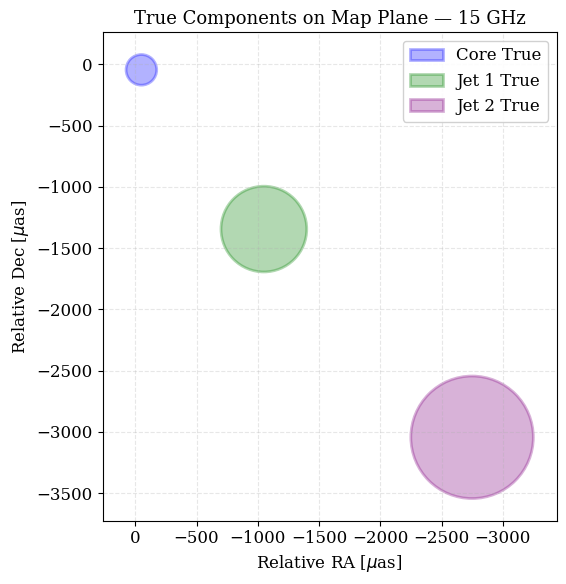

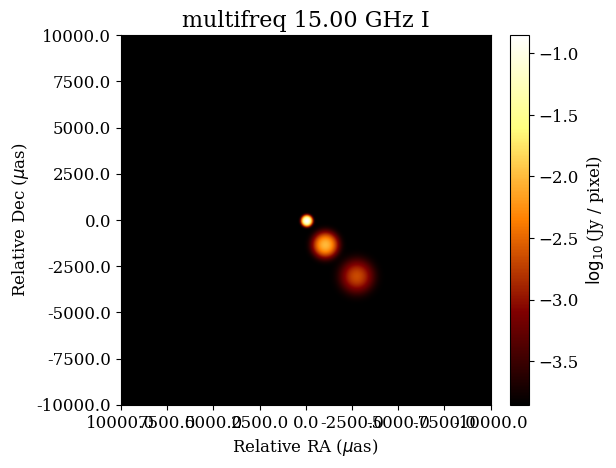

Producing clean visibilities from image with fast FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
   Applying gain corruption: ampcal-->False
Adding thermal noise to data . . . 
Scaling factor = 115.267


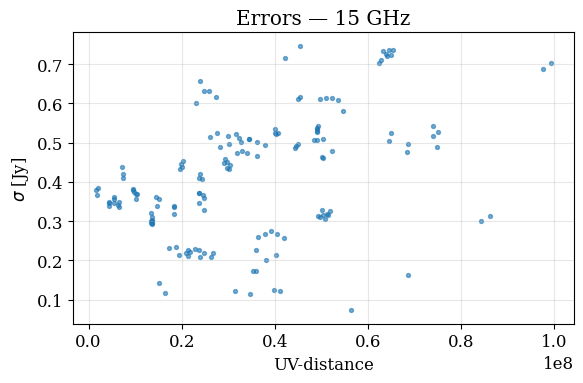


 43 GHz


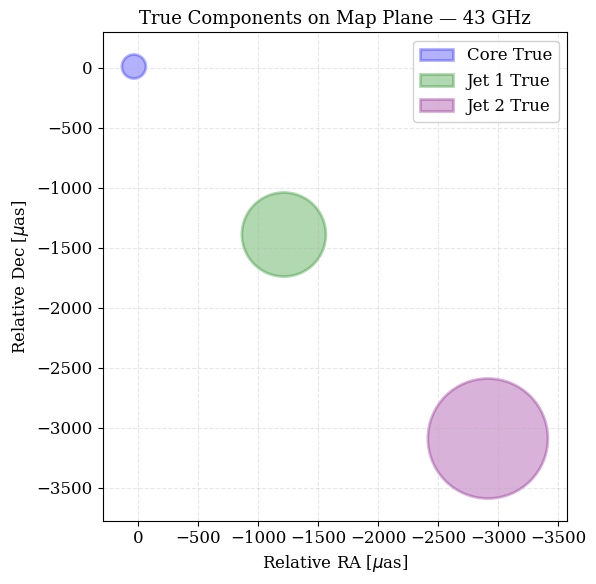

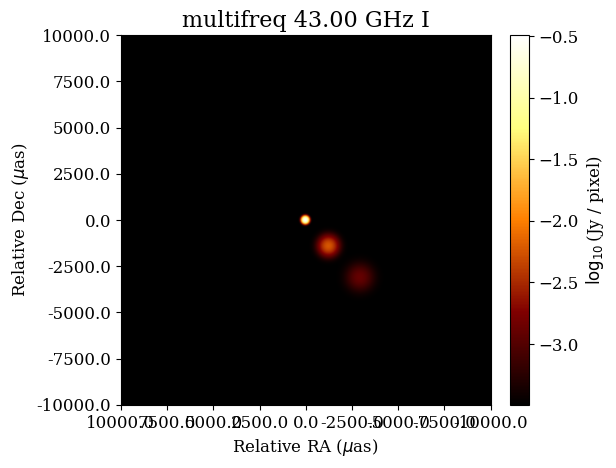

Producing clean visibilities from image with fast FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
   Applying gain corruption: ampcal-->False
Adding thermal noise to data . . . 
Scaling factor = 96.989


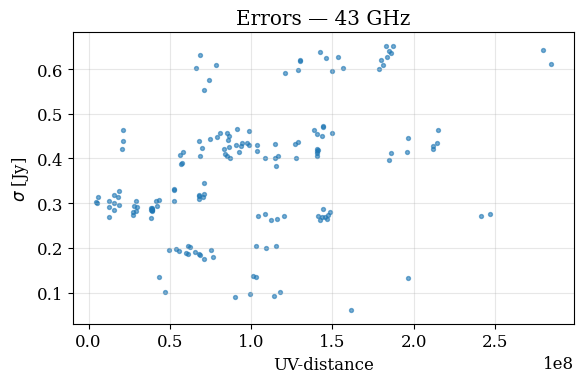


 86 GHz


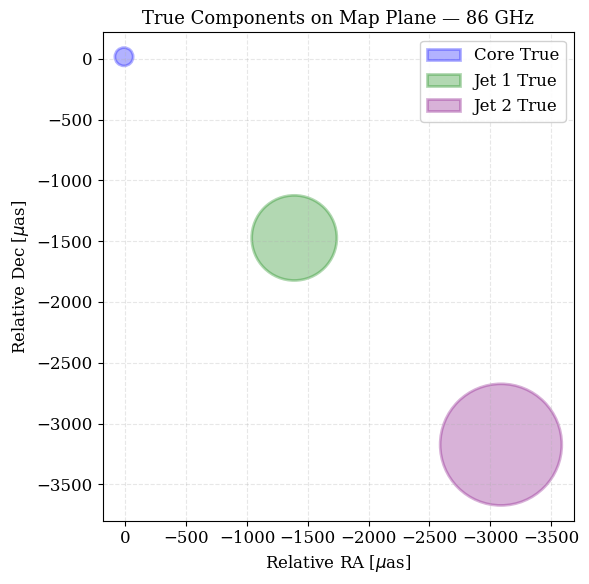

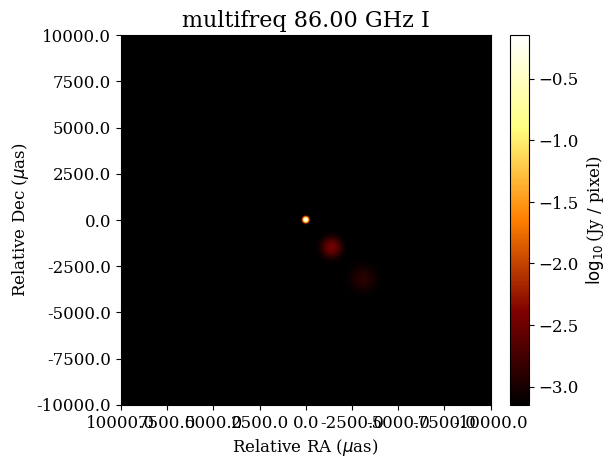

Producing clean visibilities from image with fast FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
   Applying gain corruption: ampcal-->False
Adding thermal noise to data . . . 
Scaling factor = 128.089


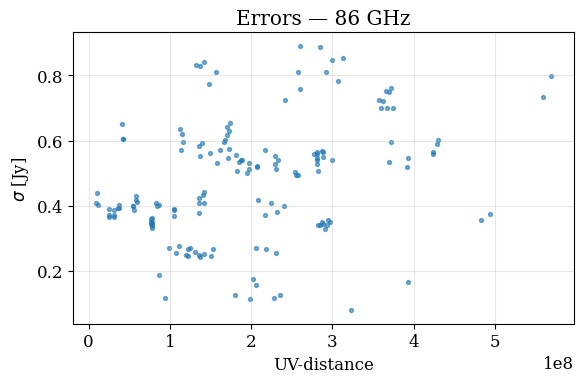

In [10]:

for freq in freqs:

    print(f"\n {freq_labels[freq]}")

    im = build_image(freq)

    obs_template = eht_array.obsdata(ra,dec,freq,bw,10.0,600.0,0.0,4.0,mjd=57757,polrep="stokes")

    obs = im.observe_same( #generate synthetic observations with ehtim, using the same array and observation setup for all frequencies, only thermal noise
        obs_template,sgrscat=False,ttype="fast",fft_pad_factor=2,add_th_noise=True,ampcal=False,phasecal=True,gainp=0.05)

    dat = obs.unpack(["u", "v", "vis", "sigma"],mode="all",conj=False)

    u = dat["u"]
    v = dat["v"]
    vis = dat["vis"]
    sigma_written = np.maximum(dat["sigma"].real,1e-6)

    #ground truth model (for error scaling)
    V_true = model_complex(
        p_true,
        freq,
        u,
        v
    )
    #empirical error scaling
    res_re = np.real(vis) - np.real(V_true) #vis minus model
    res_im = np.imag(vis) - np.imag(V_true)

    empirical_std = np.std(np.concatenate([res_re, res_im])) #std of the residuals (real and imaginary parts together)
    sigma_rms = np.sqrt(np.mean(sigma_written**2)) #RMS of the errors the synthetic dataset)
    #scaling_factor = empirical_std / sigma_rms
    #sigma_scaled = sigma_written * scaling_factor

    scaling_factor = empirical_std / sigma_written.mean()
    sigma_scaled = sigma_written * scaling_factor
    print(f"Scaling factor = {scaling_factor:.3f}")

    #errors values plot
    uvdist = np.sqrt(u**2 + v**2)
    plt.figure(figsize=(6,4))
    plt.scatter(uvdist,sigma_scaled,s=8,alpha=0.6)
    plt.xlabel("UV-distance")
    plt.ylabel(r"$\sigma$ [Jy]")
    plt.title(f"Errors — {freq_labels[freq]}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    datasets[freq] = {
        "u": u,
        "v": v,
        "vis": vis,
        "sigma": sigma_scaled
    }


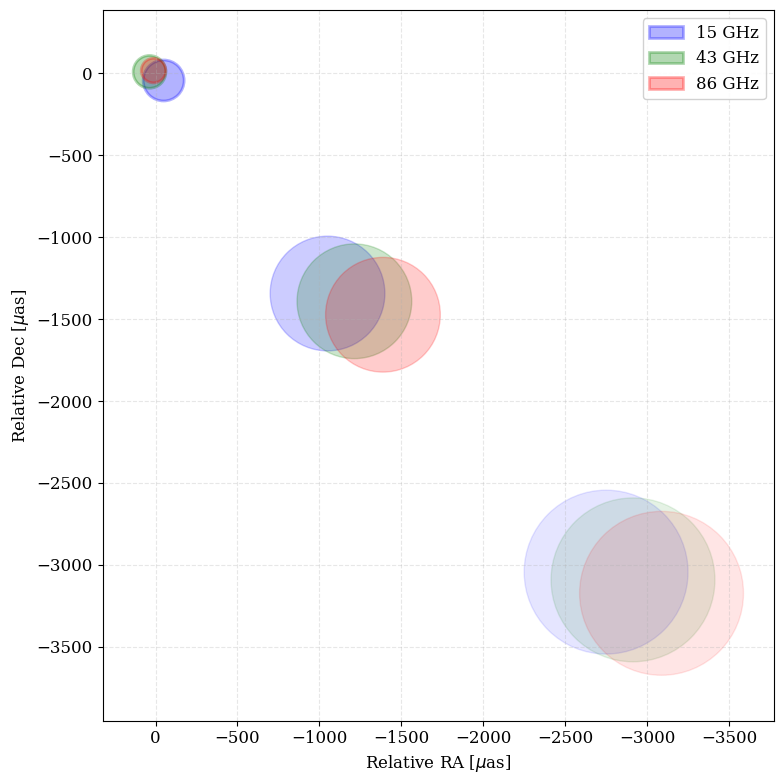

In [11]:
#all frequencies map overplotted
def plot_combined_map_planes(freqs, p_true, freq_labels):
    colors = {15e9: "blue", 43e9: "green", 86e9: "red"}
    x_j1_phys, y_j1_phys, fwhm_j1 = p_true[15], p_true[16], p_true[17]
    x_j2_phys, y_j2_phys, fwhm_j2 = p_true[21], p_true[22], p_true[23]

    fig, ax = plt.subplots(figsize=(8, 8))

    for freq in freqs:
        if freq == 15e9:
            flux_c, x_c_phys, y_c_phys, fwhm_c = p_true[0:4]
            dx, dy = p_true[24], p_true[25]
        elif freq == 43e9:
            flux_c, x_c_phys, y_c_phys, fwhm_c = p_true[4:8]
            dx, dy = p_true[26], p_true[27]
        elif freq == 86e9:
            flux_c, x_c_phys, y_c_phys, fwhm_c = p_true[8:12]
            dx, dy = p_true[28], p_true[29]

        c = colors[freq]
        lab = freq_labels[freq]

        x_c_map, y_c_map = x_c_phys - dx, y_c_phys - dy
        x_j1_map, y_j1_map = x_j1_phys - dx, y_j1_phys - dy
        x_j2_map, y_j2_map = x_j2_phys - dx, y_j2_phys - dy

        ax.add_patch(Circle((x_c_map, y_c_map), fwhm_c/2, fill=True, facecolor=c, 
                            alpha=0.3, edgecolor=c, linewidth=2, label=f"{lab}"))
        ax.add_patch(Circle((x_j1_map, y_j1_map), fwhm_j1/2, fill=True, facecolor=c, 
                            alpha=0.2, edgecolor=c, linewidth=1))
        ax.add_patch(Circle((x_j2_map, y_j2_map), fwhm_j2/2, fill=True, facecolor=c, 
                            alpha=0.1, edgecolor=c, linewidth=1))
        
    ax.invert_xaxis()
    ax.set_aspect('equal', 'datalim')
    ax.autoscale_view()
    ax.set_xlabel(r'Relative RA [$\mu$as]', fontsize=12)
    ax.set_ylabel(r'Relative Dec [$\mu$as]', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    #ax.invert_xaxis()
    ax.legend(loc='best', framealpha=0.9)
    plt.tight_layout()
    plt.show()

plot_combined_map_planes(freqs, p_true, freq_labels)

In [12]:
#residual function
def residuals_multifreq(p):
    """
    Compute the residuals for the multifrequency dataset given a set of model parameters.
    Args:  p: Array containing all the model parameters (fluxes, coordinates, sizes of the components, and map offsets)
    Returns:    Array of residuals for all frequencies concatenated together (real and imaginary parts)
    """
    residuals = []

    for freq in freqs:
        dat = datasets[freq]
        u = dat["u"]
        v = dat["v"]
        vis = dat["vis"]
        sigma = dat["sigma"]
        V_model = model_complex(p,freq,u,v)
        res_re = (
            np.real(vis) - np.real(V_model)) / sigma #this are squared later
        res_im = (
            np.imag(vis) - np.imag(V_model)) / sigma

        residuals.extend(res_re)
        residuals.extend(res_im)

    return np.array(residuals)

In [13]:
# initial guesses (p0)
P0_RANDOM_SEED = None
rng_p0 = np.random.default_rng(P0_RANDOM_SEED)

intervals = [(0.75, 0.85), (1.15, 1.25)]

def random_factor(rng):
    low, high = intervals[rng.integers(0, 2)]
    return rng.uniform(low, high)

p0 = p_true.copy()

for i in range(len(p0)):
    p0[i] = p_true[i] * random_factor(rng_p0)

# Optional: initialize map offsets at zero.
# Comment this line to use randomized offset initial guesses.
p0[24:] = 0.0


In [14]:
# bounds
lower = [
    0, -1000, -1000, fwhm_core_15_true*0.75,        # Core 15
    0, -1000, -1000, fwhm_core_43_true*0.75,        # Core 43
    0, -1000, -1000, fwhm_core_86_true*0.75,        # Core 86 
    0, 0, 0, -np.inf, -np.inf, fwhm_jet1_true*0.75, # Jet 1
    0, 0, 0, -np.inf, -np.inf, fwhm_jet2_true*0.75, # Jet 2
    -np.inf, -np.inf,                               # dx_15, dy_15
    -np.inf, -np.inf,                               # dx_43, dy_43
    -np.inf, -np.inf                                # dx_86, dy_86
]

upper = [
    20, 1000, 1000, fwhm_core_15_true*1.25,         # Core 15
    20, 1000, 1000, fwhm_core_43_true*1.25,         # Core 43
    20, 1000, 1000, fwhm_core_86_true*1.25,         # Core 86
    10, 10, 10, np.inf, np.inf, fwhm_jet1_true*1.25,# Jet 1
    10, 10, 10, np.inf, np.inf, fwhm_jet2_true*1.25,# Jet 2
    np.inf, np.inf,                                 # dx_15, dy_15
    np.inf, np.inf,                                 # dx_43, dy_43
    np.inf, np.inf                                  # dx_86, dy_86
]

result = least_squares(
    residuals_multifreq, p0,
    bounds=(lower, upper),
    method="trf", ftol=1e-10, xtol=1e-10,
)
p_best = result.x

In [15]:
# reduced chi2

res = residuals_multifreq(p_best)
chi2 = np.sum(res**2)
n_data = len(res)
n_params = len(p_best)
dof = n_data - n_params
chi2_red = chi2 / dof

print(n_data)
print(n_params)
print(dof)

print("\n==========================")
print(f"Reduced chi2 = {chi2_red:.4f}")
print("==========================")

966
30
936

Reduced chi2 = 1.7396


In [16]:
PARAMETER_NAMES = [
    "Flux_c15", "x_c15", "y_c15", "fwhm_c15",
    "Flux_c43", "x_c43", "y_c43", "fwhm_c43",
    "Flux_c86", "x_c86", "y_c86", "fwhm_c86",
    "Flux_jet1_15", "Flux_jet1_43", "Flux_jet1_86", "x_jet1", "y_jet1", "fwhm_jet1",
    "Flux_jet2_15", "Flux_jet2_43", "Flux_jet2_86", "x_jet2", "y_jet2", "fwhm_jet2",
    "dx_15","dy_15", "dx_43", "dy_43", "dx_86", "dy_86",
]

In [17]:
# report table
names = PARAMETER_NAMES

data = list(zip(names, p_true, p0, p_best))

flux_params = [d for d in data if d[0].startswith('Flux')]
pos_size_params = [d for d in data if not d[0].startswith('Flux')]

def print_table(title, subset):
    print(f"--- {title} ---")
    header = f"{'Parameter':15s} {'True':>12s} {'Guess':>12s} {'Fit':>12s} {'Delta (%)':>12s}"
    print(header)
    print("-" * len(header))
    for n, t, g, f in subset:
        delta = ((f - t) / t * 100) if t != 0 else 0
        print(f"{n:15s}{t:12.3f}{g:12.3f}{f:12.3f}{delta:12.2f} %")

print_table("FLUX PARAMETERS (Jy)", flux_params)
print_table("POSITION & SIZE PARAMETERS (µas)", pos_size_params)


--- FLUX PARAMETERS (Jy) ---
Parameter               True        Guess          Fit    Delta (%)
-------------------------------------------------------------------
Flux_c15              6.600       7.775       6.534       -1.00 %
Flux_c43              9.800      11.888       9.915        1.17 %
Flux_c86             12.000      13.823      11.933       -0.56 %
Flux_jet1_15          3.500       4.242       3.297       -5.80 %
Flux_jet1_43          2.000       2.321       1.992       -0.38 %
Flux_jet1_86          1.000       0.787       0.801      -19.93 %
Flux_jet2_15          1.500       1.751       1.522        1.48 %
Flux_jet2_43          0.700       0.844       0.888       26.89 %
Flux_jet2_86          0.400       0.312       0.354      -11.55 %
--- POSITION & SIZE PARAMETERS (µas) ---
Parameter               True        Guess          Fit    Delta (%)
-------------------------------------------------------------------
x_c15              -500.000    -401.780    -426.913      -14.62 

add initial guess to the table
for future: compare errores w/r to the beam at each frequencies

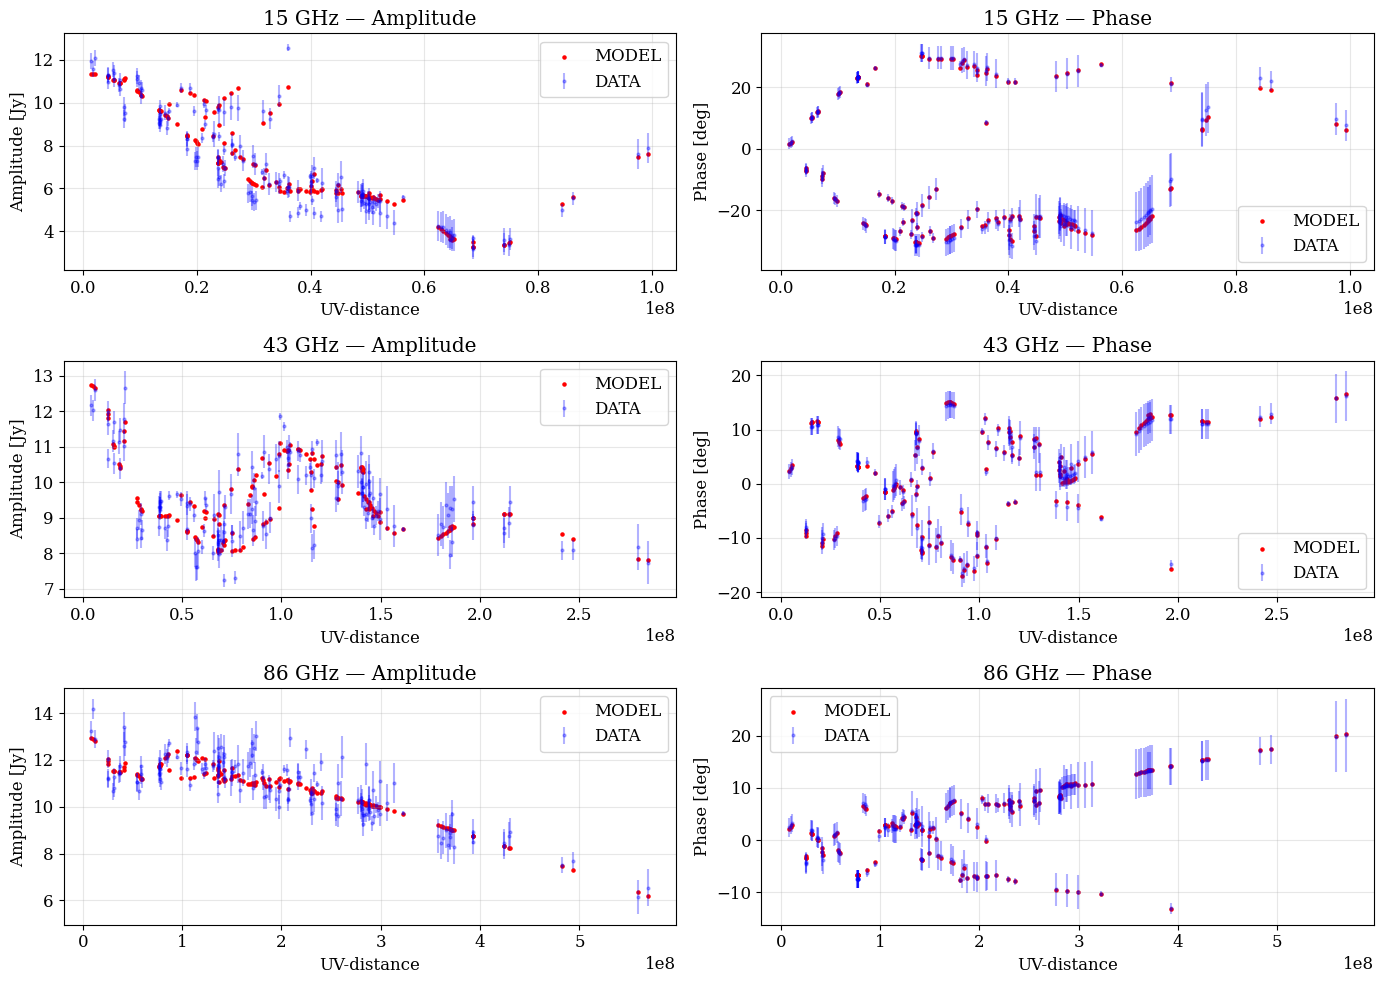

In [18]:
# radplot + phase plot
fig, axes = plt.subplots(len(freqs),2,figsize=(14,10))
colors = {
    15e9: "blue",
    43e9: "blue",
    86e9: "blue"
}

for i, freq in enumerate(freqs):
    dat = datasets[freq]
    u = dat["u"]
    v = dat["v"]
    vis = dat["vis"]
    sigma = dat["sigma"]
    V_model = model_complex(p_best,freq,u,v)
    uvdist = np.sqrt(u**2 + v**2)

    amp_obs = np.abs(vis)
    amp_mod = np.abs(V_model)

    phase_obs = np.degrees(np.angle(vis))
    phase_mod = np.degrees(np.angle(V_model))
    phase_err = np.degrees(sigma / np.maximum(amp_obs, 1e-6))

    color = colors[freq]
    #radplot
    axes[i,0].errorbar(uvdist,amp_obs,yerr=sigma,fmt='.',color=color,alpha=0.3,markersize=4,label='DATA')
    axes[i,0].scatter(uvdist,amp_mod,s=5,color='red',label='MODEL')
    axes[i,0].set_title(f'{freq_labels[freq]} — Amplitude')
    axes[i,0].set_xlabel('UV-distance')
    axes[i,0].set_ylabel('Amplitude [Jy]')
    axes[i,0].grid(alpha=0.3)
    axes[i,0].legend()
    #phase plot
    axes[i,1].errorbar(uvdist,phase_obs,yerr=phase_err,fmt='.',color=color,alpha=0.3,markersize=4,label='DATA')
    axes[i,1].scatter(uvdist,phase_mod,s=5,color='red',label='MODEL')
    axes[i,1].set_title(f'{freq_labels[freq]} — Phase')
    axes[i,1].set_xlabel('UV-distance')
    axes[i,1].set_ylabel('Phase [deg]')
    axes[i,1].grid(alpha=0.3)
    axes[i,1].legend()

plt.tight_layout()

plt.show()

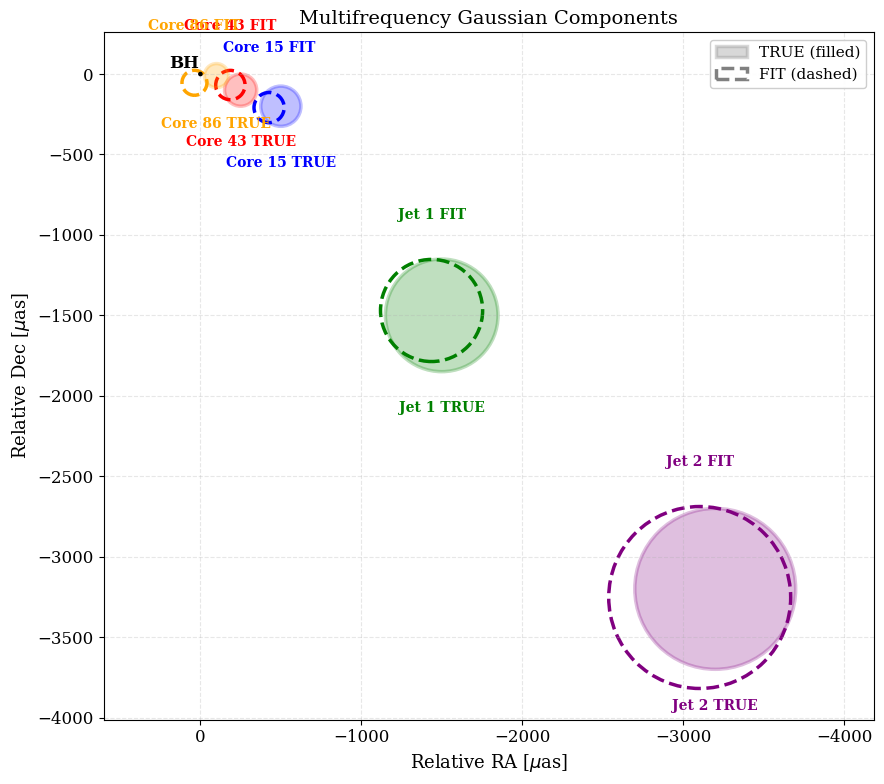

In [19]:
# all components on the map (true and fitted)

fig, ax = plt.subplots(figsize=(9,8))

#unpack best-fit parameters (f for fitted)
(
    #cores
    flux_c15_f,x_c15_f,y_c15_f,fwhm_c15_f,
    flux_c43_f,x_c43_f,y_c43_f,fwhm_c43_f,
    flux_c86_f,x_c86_f,y_c86_f,fwhm_c86_f,
    #jet 1
    flux_jet1_15_f,flux_jet1_43_f,flux_jet1_86_f, #fluxes at each frequency 
    x_jet1_f,y_jet1_f,fwhm_jet1_f, #shared position and fwhm
    #jet 2
    flux_jet2_15_f,flux_jet2_43_f,flux_jet2_86_f,
    x_jet2_f,y_jet2_f,fwhm_jet2_f,
    #different map origins
    dx_15_f,dy_15_f,
    dx_43_f,dy_43_f,
    dx_86_f,dy_86_f,
) = p_best

c15 = "blue"
c43 = "red"
c86= "orange"

jet1_color = "green"
jet2_color = "purple"

#core 15 true
circle_core15_true = Circle((x_core_15_true, y_core_15_true),fwhm_core_15_true/2,fill=True,facecolor=c15,alpha=0.25,edgecolor=c15,linestyle='-',linewidth=2.5)
ax.add_patch(circle_core15_true)
ax.text(x_core_15_true,y_core_15_true - fwhm_core_15_true/2 - 250,'Core 15 TRUE',ha='center',fontsize=10,weight='bold',color=c15)

#core 15 fit
circle_core15_fit = Circle((x_c15_f, y_c15_f),fwhm_c15_f/2,fill=False,edgecolor=c15,linestyle='--',linewidth=2.5)
ax.add_patch(circle_core15_fit)
ax.text(x_c15_f,y_c15_f + fwhm_c15_f/2 + 250,'Core 15 FIT',ha='center',fontsize=10,weight='bold',color=c15)

#core 43 true
circle_core43_true = Circle((x_core_43_true, y_core_43_true),fwhm_core_43_true/2,fill=True,facecolor=c43,alpha=0.25,edgecolor=c43,linestyle='-',linewidth=2.5)
ax.add_patch(circle_core43_true)
ax.text(x_core_43_true,y_core_43_true - fwhm_core_43_true/2 - 250,'Core 43 TRUE',ha='center',fontsize=10,weight='bold',color=c43)

#core 43 fit
circle_core43_fit = Circle((x_c43_f, y_c43_f),fwhm_c43_f/2,fill=False,edgecolor=c43,linestyle='--',linewidth=2.5)
ax.add_patch(circle_core43_fit)
ax.text(x_c43_f,y_c43_f + fwhm_c43_f/2 + 250,'Core 43 FIT',ha='center',fontsize=10,weight='bold',color=c43)

#core 86 true
circle_core86_true = Circle((x_core_86_true, y_core_86_true),fwhm_core_86_true/2,fill=True,facecolor=c86,alpha=0.25,edgecolor=c86,linestyle='-',linewidth=2.5)
ax.add_patch(circle_core86_true)
ax.text(x_core_86_true,y_core_86_true - fwhm_core_86_true/2 - 250,'Core 86 TRUE',ha='center',fontsize=10,weight='bold',color=c86)

#core 86 fit
circle_core86_fit = Circle((x_c86_f, y_c86_f),fwhm_c86_f/2,fill=False,edgecolor=c86,linestyle='--',linewidth=2.5)
ax.add_patch(circle_core86_fit)
ax.text(x_c86_f,y_c86_f + fwhm_c86_f/2 + 250,'Core 86 FIT',ha='center',fontsize=10,weight='bold',color=c86)

#jet 1 true
circle_j1_true = Circle((x_jet1_true, y_jet1_true),fwhm_jet1_true/2,fill=True,facecolor=jet1_color,alpha=0.25,edgecolor=jet1_color,linestyle='-',linewidth=2.5)
ax.add_patch(circle_j1_true)
ax.text(x_jet1_true,y_jet1_true - fwhm_jet1_true/2 - 250,'Jet 1 TRUE',ha='center',fontsize=10,weight='bold',color=jet1_color)

# jet 1 fit
circle_j1_fit = Circle((x_jet1_f, y_jet1_f),fwhm_jet1_f/2,fill=False,edgecolor=jet1_color,linestyle='--',linewidth=2.5)
ax.add_patch(circle_j1_fit)
ax.text(x_jet1_f,y_jet1_f + fwhm_jet1_f/2 + 250,'Jet 1 FIT',ha='center',fontsize=10,weight='bold',color=jet1_color)

# jet 2 true
circle_j2_true = Circle((x_jet2_true, y_jet2_true),fwhm_jet2_true/2,fill=True,facecolor=jet2_color,alpha=0.25,edgecolor=jet2_color,linestyle='-',linewidth=2.5)
ax.add_patch(circle_j2_true)
ax.text(x_jet2_true,y_jet2_true - fwhm_jet2_true/2 - 250,'Jet 2 TRUE',ha='center',fontsize=10,weight='bold',color=jet2_color)

# jet 2 fit
circle_j2_fit = Circle((x_jet2_f, y_jet2_f),fwhm_jet2_f/2,fill=False,edgecolor=jet2_color,linestyle='--',linewidth=2.5)
ax.add_patch(circle_j2_fit)
ax.text(x_jet2_f,y_jet2_f + fwhm_jet2_f/2 + 250,'Jet 2 FIT',ha='center',fontsize=10,weight='bold',color=jet2_color)

#legend
filled_circle = mpatches.Patch(facecolor='gray',alpha=0.3,edgecolor='gray',linestyle='-',linewidth=2.5,label='TRUE (filled)')
empty_circle = mpatches.Patch(fill=False,edgecolor='gray',linestyle='--',linewidth=2.5,label='FIT (dashed)')
ax.legend(handles=[filled_circle, empty_circle],loc='best',fontsize=11,framealpha=0.95)

circle_bh = Circle((0, 0), radius=10, fill=True, facecolor='black', alpha=1.0, edgecolor='black', zorder=5)
ax.add_patch(circle_bh)
ax.text(100, 15, 'BH', ha='center', va='bottom', fontsize=12, weight='bold', color='black')

ax.invert_xaxis()
ax.set_aspect('equal', 'datalim')
ax.autoscale_view()
ax.set_xlabel(r'Relative RA [$\mu$as]',fontsize=13)
ax.set_ylabel(r'Relative Dec [$\mu$as]',fontsize=13)
ax.grid(True,alpha=0.3,linestyle='--')

plt.title("Multifrequency Gaussian Components",fontsize=14)
plt.tight_layout()
plt.show()